# Análise Consumo de Álcool

In [4]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

## Read table 1
### df -> Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2)

In [5]:
df = pd.read_csv("data/alcohol.csv")
df.head()

,Unnamed: 0,"Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2)","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).1","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).2","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).3","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).4","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).5","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).6","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).7","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).8",...,"Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).50","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).51","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).52","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).53","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).54","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).55","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).56","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).57","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).58","Alcohol, total per capita (15+) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2).59"
0,NaN,2019,2019,2019,2018,2018,2018,2017,2017,2017,...,2003,2002,2002,2002,2001,2001,2001,2000,2000,2000
1,Country,Both sexes,Male,Female,Both sexes,Male,Female,Both sexes,Male,Female,...,Female,Both sexes,Male,Female,Both sexes,Male,Female,Both sexes,Male,Female
2,Afghanistan,0.0 [0.0-0.1],0.0 [0.0-0.1],0,0.0 [0.0-0.1],0.0 [0.0-0.1],0,0.0 [0.0-0.1],0.0 [0.0-0.1],0,...,0,0.0 [0.0-0.1],0.1 [0.0-0.2],0,0.0 [0.0-0.1],0.1 [0.0-0.2],0,0.0 [0.0-0.1],0.1 [0.0-0.2],0
3,Albania,6.8 [5.5-8.1],11.0 [9.1-13.5],2.5 [1.7-2.6],6.8 [5.5-8.1],11.0 [9.1-13.5],2.5 [1.7-2.6],6.7 [5.4-7.9],10.8 [8.9-13.2],2.5 [1.7-2.6],...,2.7 [1.9-2.9],7.5 [6.0-9.1],12.1 [10.0-15.3],2.9 [2.0-3.0],7.5 [5.9-9.2],12.1 [9.8-15.3],2.9 [2.0-3.0],7.5 [5.9-9.2],12.1 [9.8-15.3],2.9 [2.0-3.0]
4,Algeria,0.6 [0.5-0.8],1.1 [0.9-1.4],0.2 [0.1-0.2],0.6 [0.5-0.8],1.1 [0.9-1.4],0.2 [0.1-0.2],0.6 [0.5-0.8],1.1 [0.9-1.4],0.2 [0.1-0.2],...,0.1 [0.1-0.2],0.3 [0.3-0.5],0.6 [0.5-0.8],0.1 [0.1-0.1],0.3 [0.3-0.4],0.5 [0.4-0.7],0.1 [0.1-0.1],0.3 [0.3-0.4],0.5 [0.4-0.7],0.1 [0.1-0.1]


In [6]:
t = df.columns
for i in range(1, 61):
    df.rename(columns={t[i] : df.iloc[1,i] + "-" + df.iloc[0,i]}, inplace=True)
df.rename(columns={t[0] : "Country"}, inplace=True)
df.drop([0,1], axis=0, inplace=True)
df = df.reset_index()
df = df.iloc[:, 1:]
df.head()

,Country,Both sexes-2019,Male-2019,Female-2019,Both sexes-2018,Male-2018,Female-2018,Both sexes-2017,Male-2017,Female-2017,...,Female-2003,Both sexes-2002,Male-2002,Female-2002,Both sexes-2001,Male-2001,Female-2001,Both sexes-2000,Male-2000,Female-2000
0,Afghanistan,0.0 [0.0-0.1],0.0 [0.0-0.1],0,0.0 [0.0-0.1],0.0 [0.0-0.1],0,0.0 [0.0-0.1],0.0 [0.0-0.1],0,...,0,0.0 [0.0-0.1],0.1 [0.0-0.2],0,0.0 [0.0-0.1],0.1 [0.0-0.2],0,0.0 [0.0-0.1],0.1 [0.0-0.2],0
1,Albania,6.8 [5.5-8.1],11.0 [9.1-13.5],2.5 [1.7-2.6],6.8 [5.5-8.1],11.0 [9.1-13.5],2.5 [1.7-2.6],6.7 [5.4-7.9],10.8 [8.9-13.2],2.5 [1.7-2.6],...,2.7 [1.9-2.9],7.5 [6.0-9.1],12.1 [10.0-15.3],2.9 [2.0-3.0],7.5 [5.9-9.2],12.1 [9.8-15.3],2.9 [2.0-3.0],7.5 [5.9-9.2],12.1 [9.8-15.3],2.9 [2.0-3.0]
2,Algeria,0.6 [0.5-0.8],1.1 [0.9-1.4],0.2 [0.1-0.2],0.6 [0.5-0.8],1.1 [0.9-1.4],0.2 [0.1-0.2],0.6 [0.5-0.8],1.1 [0.9-1.4],0.2 [0.1-0.2],...,0.1 [0.1-0.2],0.3 [0.3-0.5],0.6 [0.5-0.8],0.1 [0.1-0.1],0.3 [0.3-0.4],0.5 [0.4-0.7],0.1 [0.1-0.1],0.3 [0.3-0.4],0.5 [0.4-0.7],0.1 [0.1-0.1]
3,Andorra,12.3 [10.2-14.1],18.6 [15.4-21.2],5.7 [4.8-6.6],12.3 [10.2-14.1],18.6 [15.4-21.2],5.7 [4.8-6.6],12.3 [10.3-14.1],18.7 [15.4-21.2],5.8 [4.8-6.6],...,6.2 [5.1-6.9],13.2 [11.1-14.9],19.4 [16.1-21.6],6.3 [5.2-7.1],13.4 [11.2-15.2],19.8 [16.2-22.1],6.4 [5.3-7.2],13.4 [11.2-15.2],19.8 [16.2-22.1],6.4 [5.3-7.2]
4,Angola,7.8 [6.5-9.3],12.4 [10.4-14.9],3.5 [2.9-4.2],7.8 [6.5-9.3],12.4 [10.4-14.9],3.5 [2.9-4.2],7.9 [6.6-9.3],12.5 [10.6-14.9],3.5 [2.9-4.2],...,1.5 [1.1-2.0],3.6 [2.6-4.5],5.6 [4.1-7.2],1.5 [1.1-1.9],3.3 [2.4-4.4],5.3 [3.9-6.9],1.4 [1.0-1.9],3.3 [2.4-4.4],5.3 [3.9-6.9],1.4 [1.0-1.9]


## Clean rows

In [7]:
#df.isnull().sum().sum()
df=df.dropna().reset_index(drop=True)

In [8]:
def remove_tags(line):
    resp = ""
    i = 0
    while i < len(line):
        if line[i] == '[':
            i += 1
            while line[i] != ']': i += 1
        else:
            resp += line[i]
        i += 1
    return resp
    
for i in range(1, 61):
    for j in df.iloc[:,i]:
        df.iloc[:,i].replace(j, remove_tags(j).strip(), inplace=True)

In [9]:
df.describe()

,Country,Both sexes-2019,Male-2019,Female-2019,Both sexes-2018,Male-2018,Female-2018,Both sexes-2017,Male-2017,Female-2017,...,Female-2003,Both sexes-2002,Male-2002,Female-2002,Both sexes-2001,Male-2001,Female-2001,Both sexes-2000,Male-2000,Female-2000
count,186,186,186,186,186,186,186,186,186,186,...,186,186,186,186,186,186,186,186,186,186
unique,186,103,119,60,103,119,60,98,126,59,...,65,99,125,66,110,128,72,110,128,72
top,Afghanistan,2.1,0,0,2.1,0,0,2.1,0,0.2,...,0.1,0,0,0.1,0,0,0.1,0,0,0.1
freq,1,5,5,8,5,5,8,5,5,10,...,9,5,5,9,5,5,8,5,5,8


In [10]:
df.dtypes

Country            object
Both sexes-2019    object
Male-2019          object
Female-2019        object
Both sexes-2018    object
                    ...  
Male-2001          object
Female-2001        object
Both sexes-2000    object
Male-2000          object
Female-2000        object
Length: 61, dtype: object

In [11]:
df.loc[df['Country'] == "Romania"]

,Country,Both sexes-2019,Male-2019,Female-2019,Both sexes-2018,Male-2018,Female-2018,Both sexes-2017,Male-2017,Female-2017,...,Female-2003,Both sexes-2002,Male-2002,Female-2002,Both sexes-2001,Male-2001,Female-2001,Both sexes-2000,Male-2000,Female-2000
138,Romania,12.3,19.5,5.7,12.3,19.5,5.7,12.1,19.0,5.6,...,9.3,20.2,31.4,9.7,19.2,29.9,9.2,19.2,29.9,9.2


In [12]:
#df2[:,1:].astype('float')
df.iloc[:,1:].astype('float').dtypes

Both sexes-2019    float64
Male-2019          float64
Female-2019        float64
Both sexes-2018    float64
Male-2018          float64
Female-2018        float64
Both sexes-2017    float64
Male-2017          float64
Female-2017        float64
Both sexes-2016    float64
Male-2016          float64
Female-2016        float64
Both sexes-2015    float64
Male-2015          float64
Female-2015        float64
Both sexes-2014    float64
Male-2014          float64
Female-2014        float64
Both sexes-2013    float64
Male-2013          float64
Female-2013        float64
Both sexes-2012    float64
Male-2012          float64
Female-2012        float64
Both sexes-2011    float64
Male-2011          float64
Female-2011        float64
Both sexes-2010    float64
Male-2010          float64
Female-2010        float64
Both sexes-2009    float64
Male-2009          float64
Female-2009        float64
Both sexes-2008    float64
Male-2008          float64
Female-2008        float64
Both sexes-2007    float64
M

In [13]:
years = []
for i in range (2000,2020):
    years.append(i)

In [14]:
bs = []; m = []; f = [];
sum_bs = []; sum_m = []; sum_f = []; aux = 0
for j in range(0, df.shape[0]):
    line=[]
    for i in range (1, 61, 3):
        line.append(float(df.iloc[j,i]))
        aux += float(df.iloc[j,i])
    bs.append(line)
    sum_bs.append(float(aux))
aux=0
for j in range(0, df.shape[0]):
    line=[]
    for i in range (2, 61, 3):
        line.append(float(df.iloc[j,i]))
        aux += float(df.iloc[j,i])
    m.append(line)
    sum_m.append(float(aux))
aux=0
for j in range(0, df.shape[0]):
    line=[]
    for i in range (3, 61, 3):
        line.append(float(df.iloc[j,i]))
        aux += float(df.iloc[j,i])
    f.append(line)
    sum_f.append(float(aux))

In [15]:
df.insert(1, "Sum Both-Sexes", sum_bs, True)
df.insert(2, "Sum Male", sum_m, True)
df.insert(3, "Sum Female", sum_f, True)
df.head()

,Country,Sum Both-Sexes,Sum Male,Sum Female,Both sexes-2019,Male-2019,Female-2019,Both sexes-2018,Male-2018,Female-2018,...,Female-2003,Both sexes-2002,Male-2002,Female-2002,Both sexes-2001,Male-2001,Female-2001,Both sexes-2000,Male-2000,Female-2000
0,Afghanistan,0.0,1.0,0.0,0.0,0.0,0,0.0,0.0,0,...,0,0.0,0.1,0,0.0,0.1,0,0.0,0.1,0
1,Albania,142.5,231.3,54.6,6.8,11.0,2.5,6.8,11.0,2.5,...,2.7,7.5,12.1,2.9,7.5,12.1,2.9,7.5,12.1,2.9
2,Algeria,151.8,247.5,57.2,0.6,1.1,0.2,0.6,1.1,0.2,...,0.1,0.3,0.6,0.1,0.3,0.5,0.1,0.3,0.5,0.1
3,Andorra,396.1,611.4,172.8,12.3,18.6,5.7,12.3,18.6,5.7,...,6.2,13.2,19.4,6.3,13.4,19.8,6.4,13.4,19.8,6.4
4,Angola,533.4,828.1,233.8,7.8,12.4,3.5,7.8,12.4,3.5,...,1.5,3.6,5.6,1.5,3.3,5.3,1.4,3.3,5.3,1.4


In [16]:
df.iloc[177]

Country            United States of America
Sum Both-Sexes                      21101.9
Sum Male                            33563.9
Sum Female                           9205.6
Both sexes-2019                        10.0
                             ...           
Male-2001                              14.7
Female-2001                             4.4
Both sexes-2000                         9.4
Male-2000                              14.7
Female-2000                             4.4
Name: 177, Length: 64, dtype: object

In [17]:
'''fig, ax = plt.subplots(df.shape[0], 3, figsize=(10,500))

for i in range(0, df.shape[0]):
#for i in range(0, 10):

    ax[i][0].plot(years, bs[i])
    ax[i][0].set_title('Both Sexes - ' + df.iloc[i].Country.split(' ')[0])
    ax[i][0].set_xlim([2000, 2020])
    ax[i][0].set_ylim([0, 30])
    

    ax[i][1].plot(years, m[i])
    ax[i][1].set_title('Male - ' + df.iloc[i].Country.split(' ')[0])
    ax[i][1].set_xlim([2000, 2020])
    ax[i][1].set_ylim([0, 30])
    

    ax[i][2].plot(years, f[i])
    ax[i][2].set_title('Female - ' + df.iloc[i].Country.split(' ')[0])
    ax[i][2].set_xlim([2000, 2020])
    ax[i][2].set_ylim([0, 30])
    
plt.tight_layout()
plt.show()'''

"fig, ax = plt.subplots(df.shape[0], 3, figsize=(10,500))\n\nfor i in range(0, df.shape[0]):\n#for i in range(0, 10):\n\n    ax[i][0].plot(years, bs[i])\n    ax[i][0].set_title('Both Sexes - ' + df.iloc[i].Country.split(' ')[0])\n    ax[i][0].set_xlim([2000, 2020])\n    ax[i][0].set_ylim([0, 30])\n    \n\n    ax[i][1].plot(years, m[i])\n    ax[i][1].set_title('Male - ' + df.iloc[i].Country.split(' ')[0])\n    ax[i][1].set_xlim([2000, 2020])\n    ax[i][1].set_ylim([0, 30])\n    \n\n    ax[i][2].plot(years, f[i])\n    ax[i][2].set_title('Female - ' + df.iloc[i].Country.split(' ')[0])\n    ax[i][2].set_xlim([2000, 2020])\n    ax[i][2].set_ylim([0, 30])\n    \nplt.tight_layout()\nplt.show()"

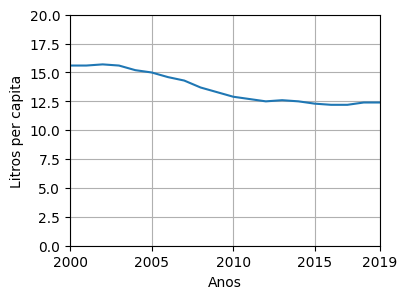

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(4,3))

ax.plot(years, m[86]) # JP -> 86
#ax.set_title('Both Sexes - ' + df.iloc[177].Country.split(' ')[0]) # US -> 177
ax.set_xlim([2000, 2019])
ax.set_ylim([0, 20])

default_x_ticks = [2000, 2005, 2010, 2015, 2019]
#plt.plot(default_x_ticks, y)
plt.xticks(default_x_ticks, [2000, 2005, 2010, 2015, 2019])

plt.xlabel("Anos")
plt.ylabel("Litros per capita")

plt.grid()
plt.show()

## Read table 2
### df1 -> Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol)

In [19]:
df1 = pd.read_csv("data/consumption.csv")
df1.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,"Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol)","Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol).1","Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol).2","Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol).3","Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol).4","Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol).5","Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol).6","Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol).7","Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol).8","Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol).9"
0,Country,Data Source,Beverage Types,2019.00,2018.00,2017.00,2016.00,2015.0,2014.00,2013.00,2012.00,2011.00,2010.00
1,Afghanistan,Data source,Wine,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00
2,Afghanistan,Data source,Beer,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.01
3,Afghanistan,Data source,Spirits,0.01,0.01,0.01,0.01,0.0,0.01,0.00,0.00,0.00,0.00
4,Afghanistan,Data source,All types,0.01,0.01,0.01,0.01,0.0,0.01,0.01,0.01,0.01,0.02


## Drop and rename columns

In [20]:
df1 = df1.iloc[:, 0:4]
#df1.head()
df1.rename(columns={"Unnamed: 0" : "Country"}, inplace=True)
df1.rename(columns={"Unnamed: 2" : "Beverage Types"}, inplace=True)
df1.rename(columns={"Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol)" : "Consumption (in litres of pure alcohol) - 2019"}, inplace=True)
df1.drop([0], axis=0, inplace=True)
del df1["Unnamed: 1"]
df1 = df1.reset_index()
df1 = df1.iloc[:, 1:5]
df1.head()
#df1.describe

,Country,Beverage Types,Consumption (in litres of pure alcohol) - 2019
0,Afghanistan,Wine,0.00
1,Afghanistan,Beer,0.00
2,Afghanistan,Spirits,0.01
3,Afghanistan,All types,0.01
4,Afghanistan,Other alcoholic beverages,0.00


## Read table 3
### df2 -> 	Nominal food and alcohol expenditures, without taxes and tips, for all purchasers

In [21]:
df2 = pd.read_excel("data/nominal_expenditures_no_taxes_tips.xlsx")
df2.head()

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

## Drop and rename column

In [ ]:
df2 = df2.iloc[:, [0, 21, 22, 23, 24, 25, 26, 27, 28]]
df2.rename(columns={"Nominal food and alcohol expenditures, without taxes and tips, for all purchasers" : "Year"}, inplace=True)
df2.rename(columns={"Unnamed: 21" : "Liquor Stores"}, inplace=True)
df2.rename(columns={"Unnamed: 22" : "Food Stores"}, inplace=True)
df2.rename(columns={"Unnamed: 23" : "Other AAH Sales"}, inplace=True)
df2.rename(columns={"Unnamed: 24" : "Total AAH"}, inplace=True)
df2.rename(columns={"Unnamed: 25" : "Eating and Drinking Places"}, inplace=True)
df2.rename(columns={"Unnamed: 26" : "Hotels and Motels"}, inplace=True)
df2.rename(columns={"Unnamed: 27" : "Other AAFH"}, inplace=True)
df2.rename(columns={"Unnamed: 28" : "Total AAFH"}, inplace=True)
df2.drop([0, 1, 2, 3], axis=0, inplace=True)
df2 = df2.loc[(df2["Year"] == 2019)]
df2 = df2.reset_index()
df2 = df2.iloc[:, 1:]
df2.head()
#df2["Nominal food and alcohol expenditures, without taxes and tips, for all purchasers"]

# Análise

## Quem bebeu mais em 2019, homens ou mulheres?

In [ ]:
sum_male = math.ceil(pd.to_numeric(df["Male-2019"], errors='coerce').sum())
sum_female = math.ceil(pd.to_numeric(df["Female-2019"], errors='coerce').sum())
print(str(sum_male) + "\t" + str(sum_female))